# Demand-side

Goal: initialize demand-side analysis with customer cohort retention views, then roll the visualization up to first-order month-of-year for easier seasonal comparison.

## Setup

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DERIVED_DATA_DIR = PROJECT_ROOT / "data" / "derived"

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.4f}".format)

PLOT_RCPARAMS = {
    "figure.figsize": (11, 6),
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2.0,
    "lines.markersize": 5,
    "patch.edgecolor": "white",
    "patch.linewidth": 0.5,
}
plt.rcParams.update(PLOT_RCPARAMS)
sns.set_theme(style="whitegrid", palette="Set2", rc=PLOT_RCPARAMS)

## Load Demand-side Tables

In [2]:
customer_fact = pd.read_csv(
    DERIVED_DATA_DIR / "customer_fact_table.csv",
    parse_dates=[
        "signup_date",
        "first_order_date",
        "second_order_date",
        "last_order_date",
        "last_return_date",
        "latest_review_date",
    ],
)

order_fact = pd.read_csv(
    DERIVED_DATA_DIR / "order_fact_table.csv",
    parse_dates=[
        "order_date",
        "order_month",
        "ship_date",
        "delivery_date",
        "first_return_date",
        "last_return_date",
        "first_review_date",
        "latest_review_date",
    ],
)

customer_cohort_activity = pd.read_csv(
    DERIVED_DATA_DIR / "customer_cohort_activity_fact.csv",
    parse_dates=[
        "first_order_cohort_month",
        "signup_cohort_month",
        "order_month",
    ],
)

signup_activation = pd.read_csv(
    DERIVED_DATA_DIR / "signup_activation_fact.csv",
    parse_dates=[
        "signup_date",
        "signup_cohort_month",
        "first_order_date",
        "second_order_date",
        "activation_month",
    ],
)

{
    "customer_fact": customer_fact.shape,
    "order_fact": order_fact.shape,
    "customer_cohort_activity": customer_cohort_activity.shape,
    "signup_activation": signup_activation.shape,
}

{'customer_fact': (121930, 46),
 'order_fact': (646945, 41),
 'customer_cohort_activity': (586976, 13),
 'signup_activation': (121930, 14)}

In [3]:
order_fact[["order_id", "order_date", "customer_id", "order_status", "device_type", "order_source"]].head()

,order_id,order_date,customer_id,order_status,device_type,order_source
0,5280,2012-07-25,1,delivered,desktop,paid_search
1,184922,2014-05-31,1,returned,mobile,referral
2,308113,2015-07-31,1,delivered,mobile,paid_search
3,483190,2017-04-23,1,delivered,mobile,paid_search
4,702081,2020-02-24,1,delivered,mobile,organic_search


# Chart 1: Funnel: Customer Order Status Flow

Compute the customer split from all customers into no-order and ordered customers, then split ordered customers into one-time and repeat buyers.

In [ ]:
funnel_customer_base = customer_fact[["customer_id", "signup_date", "orders_count"]].copy()
funnel_total_customers = int(funnel_customer_base["customer_id"].nunique())

funnel_stage = funnel_customer_base.rename(columns={"orders_count": "order_count"})
funnel_stage["order_count"] = funnel_stage["order_count"].fillna(0).astype(int)
funnel_stage["has_order"] = funnel_stage["order_count"] >= 1
funnel_stage["is_one_time_buyer"] = funnel_stage["order_count"] == 1
funnel_stage["is_repeat_buyer"] = funnel_stage["order_count"] >= 2

ordered_customers_count = int(funnel_stage["has_order"].sum())
no_order_customers_count = funnel_total_customers - ordered_customers_count
one_time_buyers_count = int(funnel_stage["is_one_time_buyer"].sum())
repeat_buyers_count = int(funnel_stage["is_repeat_buyer"].sum())

funnel_stage_counts = pd.DataFrame(
    [
        {"stage": "All Customers", "parent_stage": pd.NA, "customers": funnel_total_customers},
        {"stage": "No Order", "parent_stage": "All Customers", "customers": no_order_customers_count},
        {"stage": "Ordered Customers", "parent_stage": "All Customers", "customers": ordered_customers_count},
        {"stage": "One-time Buyers", "parent_stage": "Ordered Customers", "customers": one_time_buyers_count},
        {"stage": "Repeat Buyers", "parent_stage": "Ordered Customers", "customers": repeat_buyers_count},
    ]
)
funnel_stage_counts["share_of_parent"] = [
    1.0,
    no_order_customers_count / funnel_total_customers if funnel_total_customers > 0 else pd.NA,
    ordered_customers_count / funnel_total_customers if funnel_total_customers > 0 else pd.NA,
    one_time_buyers_count / ordered_customers_count if ordered_customers_count > 0 else pd.NA,
    repeat_buyers_count / ordered_customers_count if ordered_customers_count > 0 else pd.NA,
]
funnel_stage_counts["share_of_all_customers"] = [
    1.0,
    no_order_customers_count / funnel_total_customers if funnel_total_customers > 0 else pd.NA,
    ordered_customers_count / funnel_total_customers if funnel_total_customers > 0 else pd.NA,
    one_time_buyers_count / funnel_total_customers if funnel_total_customers > 0 else pd.NA,
    repeat_buyers_count / funnel_total_customers if funnel_total_customers > 0 else pd.NA,
]

order_join_check = order_fact[["order_id", "customer_id"]].merge(
    funnel_customer_base[["customer_id"]],
    on="customer_id",
    how="left",
    indicator=True,
)
matched_orders = int((order_join_check["_merge"] == "both").sum())
unmatched_orders = int((order_join_check["_merge"] == "left_only").sum())

funnel_checks = pd.DataFrame(
    [
        {
            "customer_order_join_coverage_pct": matched_orders / len(order_join_check) if len(order_join_check) > 0 else pd.NA,
            "orders_with_missing_customer_dim_key": unmatched_orders,
            "customers_with_missing_signup_date": int(funnel_customer_base["signup_date"].isna().sum()),
            "customers_with_missing_signup_date_pct": float(funnel_customer_base["signup_date"].isna().mean()),
            "no_order_customers_count": no_order_customers_count,
            "no_order_customers_pct": no_order_customers_count / funnel_total_customers if funnel_total_customers > 0 else pd.NA,
            "ordered_customers_count": ordered_customers_count,
            "one_time_buyers_count": one_time_buyers_count,
            "repeat_buyers_count": repeat_buyers_count,
            "buyer_split_reconciles_flag": bool(
                one_time_buyers_count + repeat_buyers_count == ordered_customers_count
            ),
        }
    ]
)

display(funnel_stage_counts)
funnel_checks

,stage,parent_stage,customers,share_of_parent,share_of_all_customers
0,All Customers,NaN,121930,1.0000,1.0000
1,No Order,All Customers,31684,0.2599,0.2599
2,Ordered Customers,All Customers,90246,0.7401,0.7401
3,One-time Buyers,Ordered Customers,22358,0.2477,0.1834
4,Repeat Buyers,Ordered Customers,67888,0.7523,0.5568


,customer_order_join_coverage_pct,orders_with_missing_customer_dim_key,customers_with_missing_signup_date,customers_with_missing_signup_date_pct,no_order_customers_count,no_order_customers_pct,ordered_customers_count,one_time_buyers_count,repeat_buyers_count,buyer_split_reconciles_flag
0,1.0000,0,0,0.0000,31684,0.2599,90246,22358,67888,True


In [13]:
import plotly.graph_objects as go

sankey_labels = [
    "All Customers",
    "Ordered Customers",
    "One-time Buyers",
    "Repeat Buyers",
    "No Order",
]
sankey_label_to_index = {label: idx for idx, label in enumerate(sankey_labels)}
sankey_node_counts = {
    "All Customers": funnel_total_customers,
    "Ordered Customers": ordered_customers_count,
    "One-time Buyers": one_time_buyers_count,
    "Repeat Buyers": repeat_buyers_count,
    "No Order": no_order_customers_count,
}
sankey_node_labels = [
    f"{label}<br>{sankey_node_counts[label]:,} ({sankey_node_counts[label] / funnel_total_customers:.1%})"
    if funnel_total_customers > 0 else label
    for label in sankey_labels
]

sankey_links = pd.DataFrame(
    [
        {"source": "All Customers", "target": "Ordered Customers", "customers": ordered_customers_count},
        {"source": "Ordered Customers", "target": "One-time Buyers", "customers": one_time_buyers_count},
        {"source": "Ordered Customers", "target": "Repeat Buyers", "customers": repeat_buyers_count},
        {"source": "All Customers", "target": "No Order", "customers": no_order_customers_count},
    ]
)
sankey_links["source_customers"] = sankey_links["source"].map(sankey_node_counts)
sankey_links["share_of_parent"] = sankey_links["customers"] / sankey_links["source_customers"]
sankey_links["share_of_all_customers"] = sankey_links["customers"] / funnel_total_customers
sankey_links["hover_count"] = sankey_links["customers"].map(lambda value: f"{value:,}")

fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node={
                "label": sankey_node_labels,
                "pad": 18,
                "thickness": 18,
                "color": ["#2f4b7c", "#a05195", "#00876c", "#ffa600", "#d45087"],
            },
            link={
                "source": sankey_links["source"].map(sankey_label_to_index),
                "target": sankey_links["target"].map(sankey_label_to_index),
                "value": sankey_links["customers"],
                "customdata": sankey_links[["hover_count", "share_of_parent", "share_of_all_customers"]],
                "hovertemplate": "%{source.label} -> %{target.label}<br>%{customdata[0]} customers<br>%{customdata[1]:.1%} of parent<br>%{customdata[2]:.1%} of all customers<extra></extra>",
            },
        )
    ]
)
fig.update_layout(
    title_text="Customer Order Status Flow",
    height=480,
    margin={"l": 20, "r": 20, "t": 60, "b": 20},
    font={"size": 12},
)
fig.show()

## Normalized Funnel Leakage Comparison

Normalize no-order customers against all customers and one-time buyers against ordered customers, so each leakage point is compared against the population that could leak at that step.

In [15]:
leakage_comparison = pd.DataFrame(
    [
        {
            "leakage_point": "No Order",
            "leakage_definition": "Customer signed up but never placed an order",
            "leakage_customers": no_order_customers_count,
            "base_population": "All Customers",
            "base_customers": funnel_total_customers,
        },
        {
            "leakage_point": "One-time Buyers",
            "leakage_definition": "Customer placed exactly one order and did not repeat",
            "leakage_customers": one_time_buyers_count,
            "base_population": "Ordered Customers",
            "base_customers": ordered_customers_count,
        },
    ]
)

leakage_comparison["normalized_leakage_rate"] = (
    leakage_comparison["leakage_customers"] / leakage_comparison["base_customers"]
)
leakage_comparison["share_of_all_customers"] = (
    leakage_comparison["leakage_customers"] / funnel_total_customers
)
leakage_comparison["customers_per_1k_base"] = (
    leakage_comparison["normalized_leakage_rate"] * 1000
).round(1)

leakage_comparison.sort_values("normalized_leakage_rate", ascending=False)

,leakage_point,leakage_definition,leakage_customers,base_population,base_customers,normalized_leakage_rate,share_of_all_customers,customers_per_1k_base
0,No Order,Customer signed up but never placed an order,31684,All Customers,121930,0.2599,0.2599,259.9000
1,One-time Buyers,Customer placed exactly one order and did not ...,22358,Ordered Customers,90246,0.2477,0.1834,247.7000


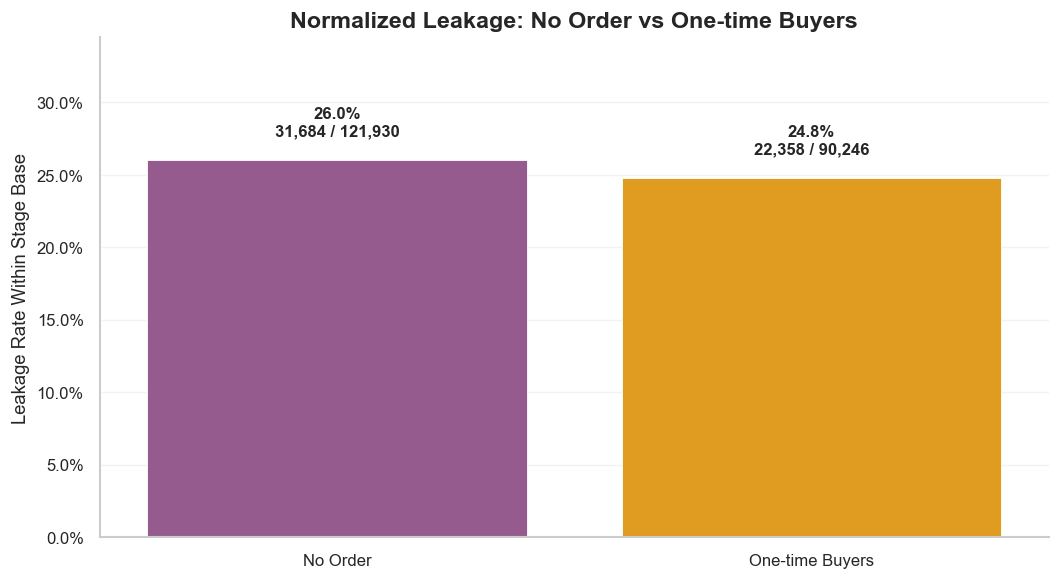

In [16]:
import matplotlib.ticker as mtick

plot_leakage = leakage_comparison.sort_values("normalized_leakage_rate", ascending=False).copy()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=plot_leakage,
    x="leakage_point",
    y="normalized_leakage_rate",
    hue="leakage_point",
    palette=["#a05195", "#ffa600"],
    legend=False,
    ax=ax,
)

for idx, row in plot_leakage.reset_index(drop=True).iterrows():
    ax.text(
        idx,
        row["normalized_leakage_rate"] + 0.015,
        f"{row['normalized_leakage_rate']:.1%}\n{int(row['leakage_customers']):,} / {int(row['base_customers']):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.set_title("Normalized Leakage: No Order vs One-time Buyers")
ax.set_xlabel("")
ax.set_ylabel("Leakage Rate Within Stage Base")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, min(1.0, plot_leakage["normalized_leakage_rate"].max() * 1.25 + 0.02))
plt.tight_layout()

### Business Insight

- **The two leakage points are almost the same size after normalization.** No Order is **31,684 / 121,930 customers = 26.0%** of all customers. One-time Buyers are **22,358 / 90,246 ordered customers = 24.8%**. The difference is only **1.2 percentage points**, so the demand problem is not concentrated in just one stage.
- **Activation leakage is slightly larger.** The biggest normalized break is still before the first order: 1 in 4 customers signs up but never buys. This means signup count alone is a weak demand signal unless activation quality is monitored.
- **Repeat leakage is also material.** Among customers who do order, **75.2% become repeat buyers** and **24.8% stop after one order**. The business is converting most buyers into repeat customers, but the one-time buyer pool is still large enough to materially reduce LTV.
- **Business risk:** acquisition can look healthy while revenue quality weakens. If paid channels or promotions bring in customers who either never order or only order once, CAC payback and demand forecasts will be overstated.
- **What to inspect next:** split both leakage points by acquisition channel, signup cohort, first-order category, discount exposure, payment method, fulfillment delay, return flag, and review score. The funnel says both activation and second-order conversion deserve attention; segmentation should identify which one is controllable first.


# Chart 2: Cohort Anchor Check

Retention is anchored on **first observed order month** rather than `signup_date`. In this dataset, many customers place an order before their recorded signup date, so signup-based retention would not represent ordering behavior cleanly.

In [18]:
cohort_anchor_check = customer_fact[["customer_id", "signup_date", "first_order_date"]].copy()
signup_after_first_order = cohort_anchor_check["first_order_date"] < cohort_anchor_check["signup_date"]

pd.DataFrame(
    [
        {
            "customers_with_orders": len(cohort_anchor_check),
            "missing_signup_date": int(cohort_anchor_check["signup_date"].isna().sum()),
            "signup_after_first_order": int(signup_after_first_order.sum()),
            "pct_signup_after_first_order": float(signup_after_first_order.mean()),
        }
    ]
)

,customers_with_orders,missing_signup_date,signup_after_first_order,pct_signup_after_first_order
0,121930,0,80623,0.6612


## Build Cohort Retention Table

In [19]:
cohort_sizes = (
    customer_fact.dropna(subset=["first_order_date"])
    .assign(cohort_month=lambda df: df["first_order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("cohort_month", as_index=False)
    .agg(cohort_size=("customer_id", "nunique"))
)

retention_counts = (
    customer_cohort_activity.rename(columns={"first_order_cohort_month": "cohort_month"})
    .groupby(["cohort_month", "cohort_index"], as_index=False)
    .agg(active_customers=("customer_id", "nunique"))
    .merge(cohort_sizes, on="cohort_month", how="left")
)
retention_counts["retention_rate"] = retention_counts["active_customers"] / retention_counts["cohort_size"]
retention_counts["cohort_start_month"] = retention_counts["cohort_month"].dt.month_name().str.slice(stop=3)

retention_counts.head(12)

,cohort_month,cohort_index,active_customers,cohort_size,retention_rate,cohort_start_month
0,2012-07-01,0,4883,4883,1.0000,Jul
1,2012-07-01,1,673,4883,0.1378,Jul
2,2012-07-01,2,589,4883,0.1206,Jul
3,2012-07-01,3,440,4883,0.0901,Jul
4,2012-07-01,4,443,4883,0.0907,Jul
5,2012-07-01,5,632,4883,0.1294,Jul
6,2012-07-01,6,419,4883,0.0858,Jul
7,2012-07-01,7,487,4883,0.0997,Jul
8,2012-07-01,8,692,4883,0.1417,Jul
9,2012-07-01,9,879,4883,0.1800,Jul


In [20]:
retention_heatmap = retention_counts.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="retention_rate",
)
retention_heatmap.iloc[:8, :8]

cohort_index,0,1,2,3,4,5,6,7
cohort_month,,,,,,,,
2012-07-01,1.0000,0.1378,0.1206,0.0901,0.0907,0.1294,0.0858,0.0997
2012-08-01,1.0000,0.1134,0.0918,0.0917,0.1245,0.0751,0.0897,0.1243
2012-09-01,1.0000,0.0947,0.0856,0.1190,0.0804,0.0845,0.1154,0.1566
2012-10-01,1.0000,0.0822,0.1198,0.0734,0.0959,0.1172,0.1529,0.1419
2012-11-01,1.0000,0.1226,0.0661,0.0884,0.1090,0.1248,0.1322,0.1327
2012-12-01,1.0000,0.0592,0.0732,0.0999,0.1250,0.1293,0.1241,0.1108
2013-01-01,1.0000,0.0766,0.0939,0.1367,0.1171,0.1254,0.1129,0.1111
2013-02-01,1.0000,0.0982,0.1298,0.1204,0.1199,0.1043,0.0940,0.0855


## Month-of-year Cohort Retention Heatmap

The detailed cohort table above is retained for inspection. For visualization, cohorts are grouped by the **month of first order** across years so the seasonal pattern is easier to compare.

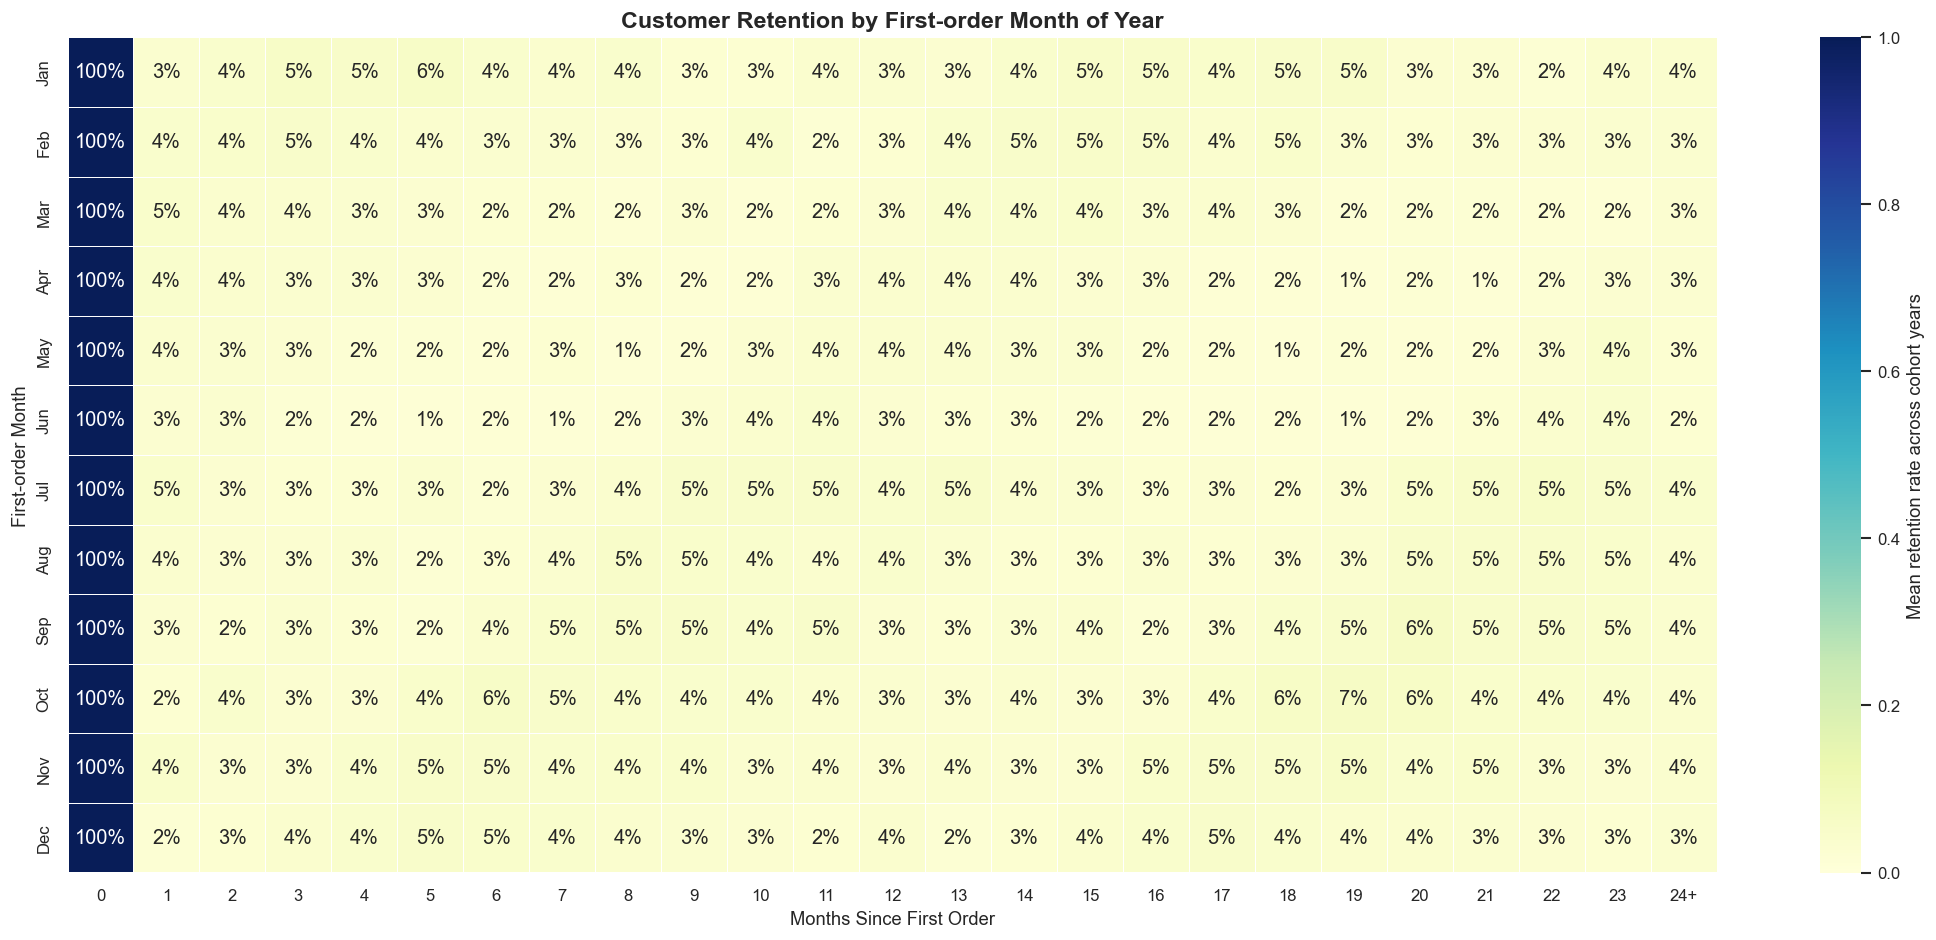

In [21]:
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",
]
bucket_order = list(range(24)) + ["24+"]

retention_counts["cohort_index_bucket"] = retention_counts["cohort_index"].where(
    retention_counts["cohort_index"] < 24,
    "24+",
)

month_of_year_retention = (
    retention_counts.groupby(["cohort_start_month", "cohort_index_bucket"], as_index=False)
    .agg(
        mean_retention_rate=("retention_rate", "mean"),
        cohorts=("cohort_month", "nunique"),
    )
)
month_of_year_heatmap = (
    month_of_year_retention.pivot(
        index="cohort_start_month",
        columns="cohort_index_bucket",
        values="mean_retention_rate",
    )
    .reindex(index=month_order)
    .reindex(columns=bucket_order)
)
heatmap_labels = month_of_year_heatmap.map(lambda value: f"{value:.0%}" if pd.notna(value) else "")

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    month_of_year_heatmap,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.4,
    linecolor="white",
    annot=heatmap_labels,
    fmt="",
    cbar_kws={"label": "Mean retention rate across cohort years"},
    ax=ax,
)
ax.set_title("Customer Retention by First-order Month of Year")
ax.set_xlabel("Months Since First Order")
ax.set_ylabel("First-order Month")
plt.tight_layout()

## Year-grouped Cohort Retention Heatmap

This view groups first-order cohorts by calendar year instead of month-of-year, using the same `24+` horizon bucket to keep the chart readable.

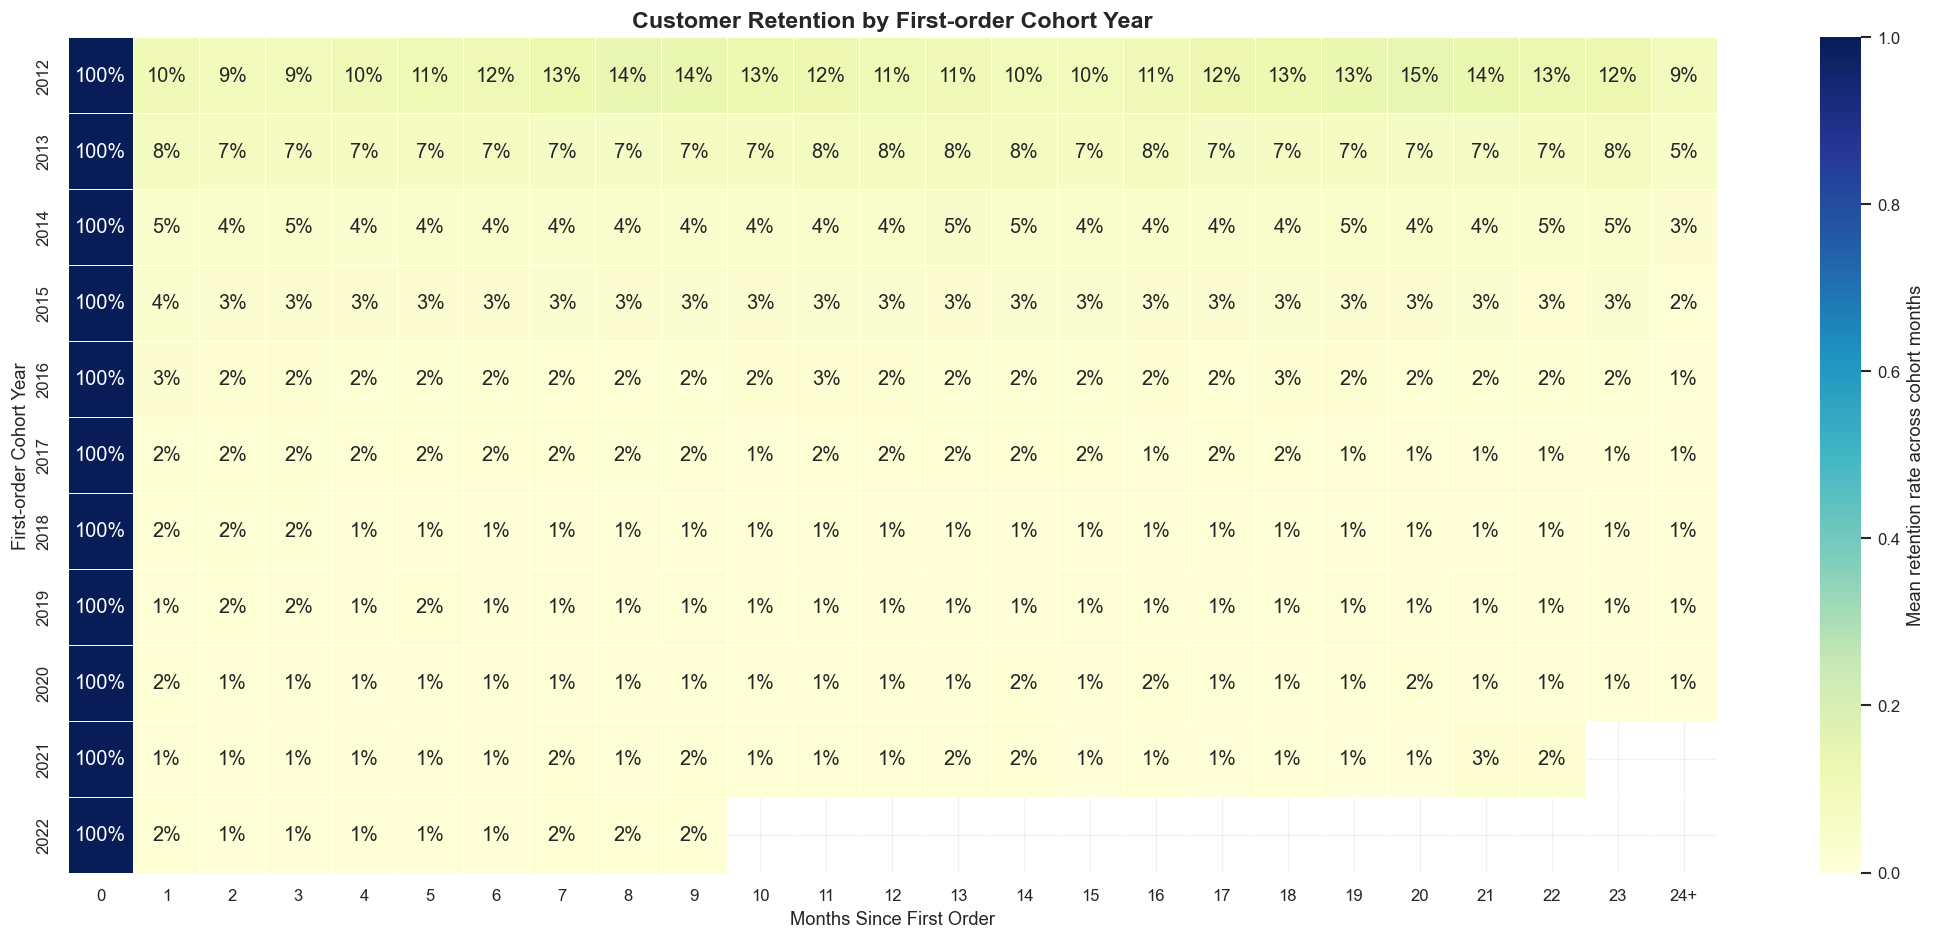

In [22]:
retention_counts["cohort_year"] = retention_counts["cohort_month"].dt.year

year_of_cohort_retention = (
    retention_counts.groupby(["cohort_year", "cohort_index_bucket"], as_index=False)
    .agg(
        mean_retention_rate=("retention_rate", "mean"),
        cohorts=("cohort_month", "nunique"),
    )
)
year_of_cohort_heatmap = (
    year_of_cohort_retention.pivot(
        index="cohort_year",
        columns="cohort_index_bucket",
        values="mean_retention_rate",
    )
    .sort_index()
    .reindex(columns=bucket_order)
)
heatmap_labels = year_of_cohort_heatmap.map(lambda value: f"{value:.0%}" if pd.notna(value) else "")

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    year_of_cohort_heatmap,
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    linewidths=0.4,
    linecolor="white",
    annot=heatmap_labels,
    fmt="",
    cbar_kws={"label": "Mean retention rate across cohort months"},
    ax=ax,
)
ax.set_title("Customer Retention by First-order Cohort Year")
ax.set_xlabel("Months Since First Order")
ax.set_ylabel("First-order Cohort Year")
plt.tight_layout()

### Business Insight

- **Story connection from the funnel:** the Sankey showed two similar leakage pools: **26.0% of all customers never order**, and **24.8% of ordered customers buy only once**. The heatmap explains what happens inside the ordered-customer branch after the first purchase: repeat behavior exists, but it is thin and spread over time rather than concentrated in strong monthly retention.
- **The funnel repeat-buyer rate can look stronger than the monthly cohort view.** The funnel says **75.2% of ordered customers eventually repeat**, but the heatmap shows average active retention of only **3.6% at month 1**, **3.2% at month 6**, **3.4% at month 12**, and **3.4% in the 24+ bucket**. This means many repeat customers do not necessarily come back in a predictable monthly cadence.
- **Seasonality shapes the second-order opportunity.** Month 1 retention is strongest for first orders in **March (4.7%)** and **July (4.6%)**, while **December (2.3%)** and **October (2.4%)** are weakest. At month 6, **October cohorts lead at 5.8%**, while **May (1.6%)** and **June (2.0%)** are weakest. This connects back to the funnel: reducing one-time buyers likely requires different timing and messaging depending on first-order month.
- **High-volume months are not automatically high-quality cohorts.** July and August have the largest average cohort sizes, around **1,017-1,021 customers per cohort month**, but July is weak at month 6 (**2.2%**) and June is weak at both month 3 (**2.0%**) and month 6 (**2.0%**). So the demand story is not just 'peak season brings customers'; the follow-up question is whether those peak-season customers become durable repeat buyers.
- **The year heatmap adds a warning to the funnel story.** Month 1 retention falls from **10.2% for 2012 cohorts** to roughly **1.7% for 2022 cohorts**. Month 12 retention falls from **11.1% in 2012** to about **1.4% in 2021**. Even if the current funnel still shows a large repeat-buyer branch, newer cohorts appear to repeat less consistently by month, which threatens future LTV.
- **Business risk:** the business may be solving the wrong problem if it only looks at the funnel. The funnel says activation and one-time-buyer leakage are both material; the heatmap adds that repeat demand is low-frequency, seasonal, and weakening by cohort year. CAC, CRM timing, inventory planning, and LTV forecasts should not assume repeat buyers return quickly or uniformly.
- **What to inspect next:** segment the funnel and heatmap together by acquisition channel, first-order category, discount use, fulfillment delay, return status, review score, and net revenue. The goal is to find which segments both activate into first order and sustain healthier retention after first order.


## Retention Milestones

In [23]:
summary_months = [0, 1, 3, 6, 12]
retention_summary = (
    retention_counts[retention_counts["cohort_index"].isin(summary_months)]
    .pivot(index="cohort_month", columns="cohort_index", values="retention_rate")
    .rename(columns={month: f"m{month}" for month in summary_months if month in retention_counts["cohort_index"].values})
    .join(cohort_sizes.set_index("cohort_month"))
    .sort_index()
)
retention_summary.tail(12)

,m0,m1,m3,m6,m12,cohort_size
cohort_month,,,,,,
2022-01-01,1.0000,NaN,0.0189,NaN,NaN,53
2022-02-01,1.0000,0.0128,NaN,NaN,NaN,78
2022-03-01,1.0000,0.0234,0.0058,NaN,NaN,171
2022-04-01,1.0000,0.0123,0.0123,0.0062,NaN,162
2022-05-01,1.0000,0.0307,0.0123,NaN,NaN,163
2022-06-01,1.0000,0.0059,0.0059,0.0176,NaN,170
2022-07-01,1.0000,NaN,NaN,NaN,NaN,113
2022-08-01,1.0000,NaN,0.0076,NaN,NaN,132
2022-09-01,1.0000,NaN,0.0109,NaN,NaN,92


In [8]:
import matplotlib.ticker as mtick

customer_fact.shape, order_fact.shape, customer_cohort_activity.shape, signup_activation.shape

((121930, 46), (646945, 41), (586976, 13))

## Time-to-second-purchase Distribution

Compute the days from first to second order for repeat buyers, summarize median/IQR/p75/p90, and run window checks so recent cohorts are not overinterpreted.

In [9]:
repeat_base = customer_fact.loc[
    customer_fact["first_order_date"].notna(),
    ["customer_id", "first_order_date", "second_order_date", "orders_count"],
]
repeat_base["orders_count"] = repeat_base["orders_count"].fillna(0)

repeat_candidates = repeat_base[
    (repeat_base["orders_count"] >= 2) | repeat_base["second_order_date"].notna()
]
repeat_candidates["days_to_second_order_calc"] = (
    repeat_candidates["second_order_date"] - repeat_candidates["first_order_date"]
).dt.days

invalid_gap_mask = repeat_candidates["days_to_second_order_calc"].isna() | (
    repeat_candidates["days_to_second_order_calc"] <= 0
)
valid_repeat_gaps = repeat_candidates.loc[~invalid_gap_mask, "days_to_second_order_calc"]

gap_quantiles = valid_repeat_gaps.quantile([0.25, 0.50, 0.75, 0.90])
median_gap = gap_quantiles.loc[0.50]
iqr_gap = gap_quantiles.loc[0.75] - gap_quantiles.loc[0.25]
p75_gap = gap_quantiles.loc[0.75]
p90_gap = gap_quantiles.loc[0.90]

analysis_end_date = order_fact["order_date"].max()
repeat_base["observable_window_days"] = (
    analysis_end_date - repeat_base["first_order_date"]
).dt.days
repeat_base["eligible_for_p90_window"] = repeat_base["observable_window_days"] >= p90_gap
repeat_base["is_valid_repeater"] = repeat_base["customer_id"].isin(
    repeat_candidates.loc[~invalid_gap_mask, "customer_id"]
)

gap_summary = pd.DataFrame(
    [
        {
            "repeat_buyers_candidates": int(len(repeat_candidates)),
            "valid_repeat_gaps_used": int(valid_repeat_gaps.shape[0]),
            "removed_invalid_zero_or_negative_gap": int(invalid_gap_mask.sum()),
            "median_days": float(median_gap),
            "iqr_days": float(iqr_gap),
            "p75_days": float(p75_gap),
            "p90_days": float(p90_gap),
        }
    ]
)

window_check = pd.DataFrame(
    [
        {
            "analysis_end_date": analysis_end_date,
            "p90_gap_days": float(p90_gap),
            "purchasers_total": int(len(repeat_base)),
            "purchasers_eligible_for_p90_window": int(repeat_base["eligible_for_p90_window"].sum()),
            "eligible_share": float(repeat_base["eligible_for_p90_window"].mean()),
            "repeat_rate_all_purchasers": float(repeat_base["is_valid_repeater"].mean()),
            "repeat_rate_p90_eligible_only": float(
                repeat_base.loc[
                    repeat_base["eligible_for_p90_window"],
                    "is_valid_repeater",
                ].mean()
            ),
        }
    ]
)

cohort_window_check = (
    repeat_base.assign(
        first_order_cohort_month=repeat_base["first_order_date"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("first_order_cohort_month", as_index=False)
    .agg(
        purchasers=("customer_id", "nunique"),
        eligible_for_p90_window=("eligible_for_p90_window", "sum"),
        valid_repeaters=("is_valid_repeater", "sum"),
    )
    .sort_values("first_order_cohort_month")
)
cohort_window_check["eligibility_rate"] = (
    cohort_window_check["eligible_for_p90_window"] / cohort_window_check["purchasers"]
)
cohort_window_check["repeat_rate_observed"] = (
    cohort_window_check["valid_repeaters"] / cohort_window_check["purchasers"]
)
cohort_window_check["repeat_rate_eligible_only"] = (
    cohort_window_check["valid_repeaters"]
    / cohort_window_check["eligible_for_p90_window"].replace(0, pd.NA)
)

cohort_horizon = (
    customer_cohort_activity.groupby("first_order_cohort_month", as_index=False)["cohort_index"]
    .max()
    .rename(columns={"cohort_index": "max_observed_cohort_index"})
)
cohort_window_check = cohort_window_check.merge(
    cohort_horizon,
    on="first_order_cohort_month",
    how="left",
)

display(gap_summary)
display(window_check)
cohort_window_check.tail(12)

,repeat_buyers_candidates,valid_repeat_gaps_used,removed_invalid_zero_or_negative_gap,median_days,iqr_days,p75_days,p90_days
0,67888,67320,568,299.0000,618.2500,717.2500,1365.0000


,analysis_end_date,p90_gap_days,purchasers_total,purchasers_eligible_for_p90_window,eligible_share,repeat_rate_all_purchasers,repeat_rate_p90_eligible_only
0,2022-12-31,1365.0000,90246,84664,0.9381,0.7460,0.7856


,first_order_cohort_month,purchasers,eligible_for_p90_window,valid_repeaters,eligibility_rate,repeat_rate_observed,repeat_rate_eligible_only,max_observed_cohort_index
114,2022-01-01,53,0,6,0.0000,0.1132,<NA>,9
115,2022-02-01,78,0,2,0.0000,0.0256,<NA>,7
116,2022-03-01,171,0,8,0.0000,0.0468,<NA>,5
117,2022-04-01,162,0,8,0.0000,0.0494,<NA>,7
118,2022-05-01,163,0,15,0.0000,0.0920,<NA>,7
119,2022-06-01,170,0,11,0.0000,0.0647,<NA>,6
120,2022-07-01,113,0,3,0.0000,0.0265,<NA>,5
121,2022-08-01,132,0,3,0.0000,0.0227,<NA>,4
122,2022-09-01,92,0,3,0.0000,0.0326,<NA>,3
123,2022-10-01,51,0,0,0.0000,0.0000,<NA>,0


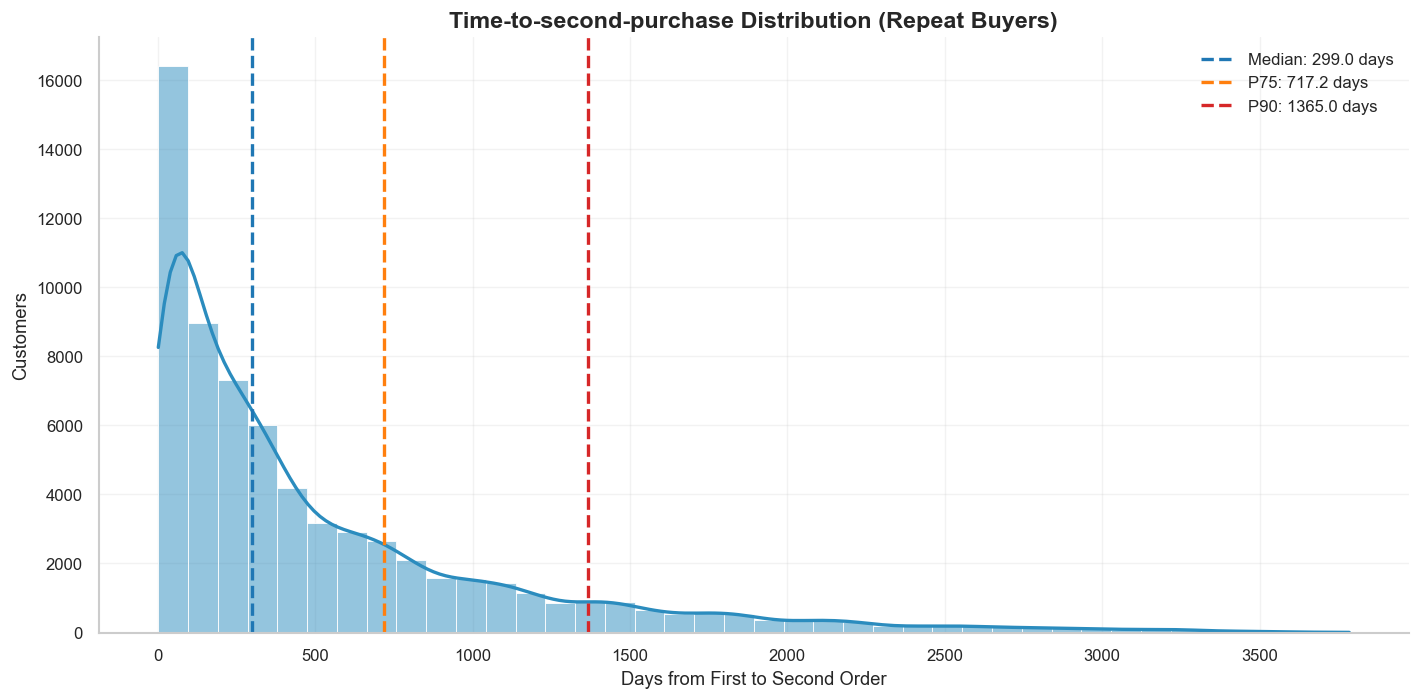

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(valid_repeat_gaps, bins=40, kde=True, color="#2b8cbe", ax=ax)

for label, value, color in [
    ("Median", median_gap, "#1f77b4"),
    ("P75", p75_gap, "#ff7f0e"),
    ("P90", p90_gap, "#d62728"),
]:
    ax.axvline(value, color=color, linestyle="--", linewidth=2, label=f"{label}: {value:.1f} days")

ax.set_title("Time-to-second-purchase Distribution (Repeat Buyers)")
ax.set_xlabel("Days from First to Second Order")
ax.set_ylabel("Customers")
ax.legend(loc="upper right")
plt.tight_layout()

## Repeat Rate by Acquisition Channel

Compute customer count, purchaser count, repeat customer count, and repeat rate per channel, then check missingness and group tiny channels into Other.

In [11]:
channel_base = customer_fact[["customer_id", "acquisition_channel", "orders_count"]].copy()
channel_base["orders_count"] = channel_base["orders_count"].fillna(0)

channel_base["acquisition_channel_clean"] = (
    channel_base["acquisition_channel"].astype("string").str.strip()
)
missing_channel_mask = channel_base["acquisition_channel_clean"].isna() | (
    channel_base["acquisition_channel_clean"] == ""
 )
channel_base.loc[missing_channel_mask, "acquisition_channel_clean"] = "Unknown"

channel_stats = (
    channel_base.groupby("acquisition_channel_clean", as_index=False)
    .agg(
        customer_count=("customer_id", "nunique"),
        purchaser_count=("orders_count", lambda values: int((values > 0).sum())),
        repeat_customer_count=("orders_count", lambda values: int((values >= 2).sum())),
    )
)
channel_stats["repeat_rate"] = (
    channel_stats["repeat_customer_count"]
    / channel_stats["purchaser_count"].replace(0, pd.NA)
)

channel_missingness = pd.DataFrame(
    [
        {
            "customers_total": int(channel_base["customer_id"].nunique()),
            "missing_or_blank_channel_customers": int(missing_channel_mask.sum()),
            "missing_or_blank_channel_pct": float(missing_channel_mask.mean()),
        }
    ]
)

min_customer_threshold = max(50, int(0.01 * channel_base["customer_id"].nunique()))
small_channels = channel_stats.loc[
    channel_stats["customer_count"] < min_customer_threshold,
    [
        "acquisition_channel_clean",
        "customer_count",
        "purchaser_count",
        "repeat_customer_count",
        "repeat_rate",
    ],
]
small_channels = small_channels.sort_values("customer_count")

channel_stats["channel_grouped"] = channel_stats["acquisition_channel_clean"].where(
    channel_stats["customer_count"] >= min_customer_threshold,
    "Other",
)

channel_grouped = (
    channel_stats.groupby("channel_grouped", as_index=False)
    .agg(
        customer_count=("customer_count", "sum"),
        purchaser_count=("purchaser_count", "sum"),
        repeat_customer_count=("repeat_customer_count", "sum"),
    )
)
channel_grouped["repeat_rate"] = (
    channel_grouped["repeat_customer_count"]
    / channel_grouped["purchaser_count"].replace(0, pd.NA)
)
channel_grouped = channel_grouped.sort_values("repeat_rate", ascending=False).reset_index(drop=True)

display(channel_missingness)
display(
    pd.DataFrame(
        [
            {
                "tiny_channel_threshold_customers": min_customer_threshold,
                "num_tiny_channels_grouped_into_other": int(small_channels.shape[0]),
            }
        ]
    )
)
display(small_channels)
channel_grouped

,customers_total,missing_or_blank_channel_customers,missing_or_blank_channel_pct
0,121930,0,0.0000


,tiny_channel_threshold_customers,num_tiny_channels_grouped_into_other
0,1219,0


,acquisition_channel_clean,customer_count,purchaser_count,repeat_customer_count,repeat_rate


,channel_grouped,customer_count,purchaser_count,repeat_customer_count,repeat_rate
0,social_media,24448,18002,13623,0.7567
1,organic_search,36450,26950,20316,0.7538
2,referral,12270,9072,6816,0.7513
3,paid_search,24285,17999,13503,0.7502
4,direct,9803,7337,5491,0.7484
5,email_campaign,14674,10886,8139,0.7477


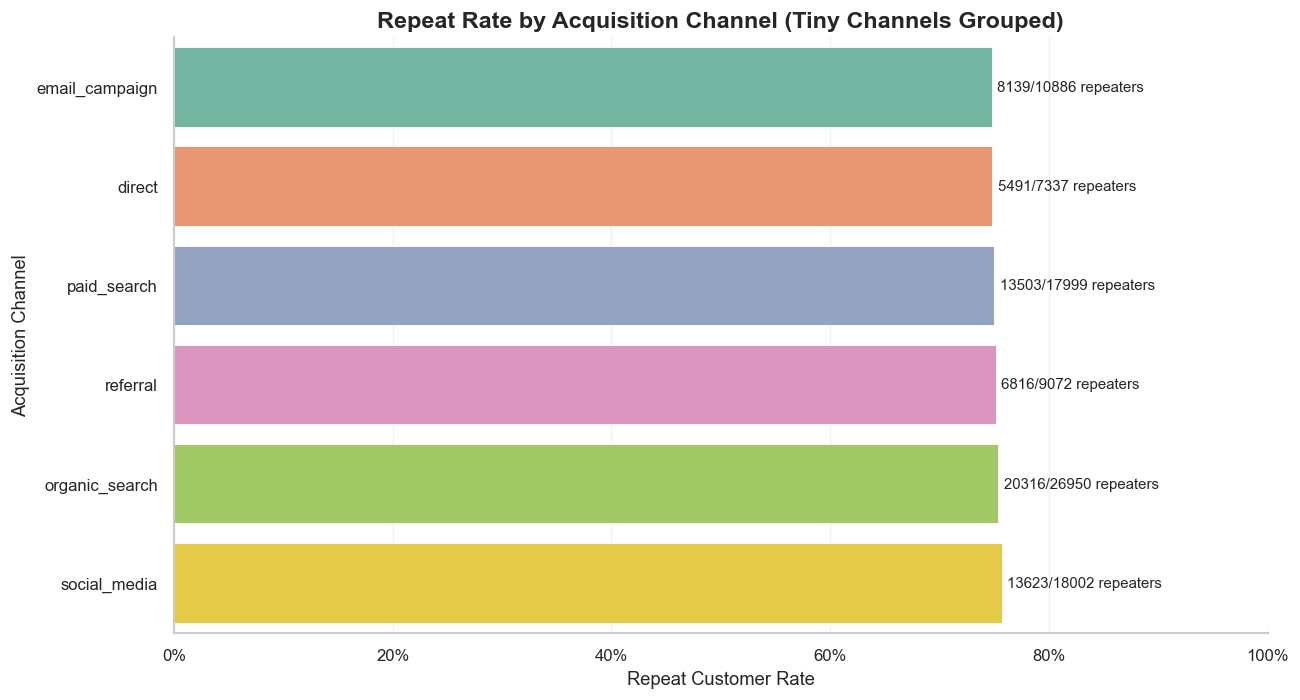

In [15]:
plot_channel = channel_grouped.sort_values("repeat_rate", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(
    data=plot_channel,
    x="repeat_rate",
    y="channel_grouped",
    hue="channel_grouped",
    palette="Set2",
    legend=False,
    ax=ax,
)

for idx, row in plot_channel.iterrows():
    rate_value = row["repeat_rate"]
    if pd.notna(rate_value):
        ax.text(
            min(rate_value + 0.005, 0.99),
            idx,
            f"{int(row['repeat_customer_count'])}/{int(row['purchaser_count'])} repeaters",
            va="center",
            fontsize=9,
        )

max_rate = plot_channel["repeat_rate"].max()
xmax = 1.0 if pd.isna(max_rate) else min(1.0, float(max_rate) * 1.35 + 0.02)
ax.set_xlim(0, xmax)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Repeat Rate by Acquisition Channel (Tiny Channels Grouped)")
ax.set_xlabel("Repeat Customer Rate")
ax.set_ylabel("Acquisition Channel")
plt.tight_layout()

## Customer Revenue Concentration Curve

Build a cumulative concentration curve from customer-level revenue contribution, with a consistency check against order-level revenue and an optional order-count concentration comparison.

In [13]:
revenue_metric = "net_revenue_proxy" if "net_revenue_proxy" in customer_fact.columns else "net_revenue"

revenue_base = customer_fact.loc[
    customer_fact["first_order_date"].notna(),
    ["customer_id", "orders_count", revenue_metric],
]
revenue_base["orders_count"] = revenue_base["orders_count"].fillna(0)
revenue_base[revenue_metric] = revenue_base[revenue_metric].fillna(0.0)

order_revenue_by_customer = (
    order_fact.groupby("customer_id", as_index=False)[revenue_metric]
    .sum()
    .rename(columns={revenue_metric: "order_fact_revenue"})
)

revenue_consistency = revenue_base.merge(order_revenue_by_customer, on="customer_id", how="left")
revenue_consistency["order_fact_revenue"] = revenue_consistency["order_fact_revenue"].fillna(0.0)
revenue_consistency["abs_gap"] = (
    revenue_consistency[revenue_metric] - revenue_consistency["order_fact_revenue"]
).abs()

consistency_summary = pd.DataFrame(
    [
        {
            "revenue_metric_used": revenue_metric,
            "total_revenue_customer_fact": float(revenue_consistency[revenue_metric].sum()),
            "total_revenue_order_fact": float(revenue_consistency["order_fact_revenue"].sum()),
            "absolute_total_gap": float(
                abs(
                    revenue_consistency[revenue_metric].sum()
                    - revenue_consistency["order_fact_revenue"].sum()
                )
            ),
            "median_abs_customer_gap": float(revenue_consistency["abs_gap"].median()),
            "p95_abs_customer_gap": float(revenue_consistency["abs_gap"].quantile(0.95)),
            "customers_with_abs_gap_gt_1": int((revenue_consistency["abs_gap"] > 1).sum()),
        }
    ]
)

non_positive_revenue_customers = int((revenue_base[revenue_metric] <= 0).sum())
concentration_base = revenue_base.loc[revenue_base[revenue_metric] > 0].copy()

revenue_curve = concentration_base.sort_values(revenue_metric, ascending=False).reset_index(drop=True)
revenue_curve["cum_customer_share"] = (revenue_curve.index + 1) / len(revenue_curve)
revenue_curve["cum_revenue_share"] = (
    revenue_curve[revenue_metric].cumsum() / revenue_curve[revenue_metric].sum()
)

order_curve = concentration_base.sort_values("orders_count", ascending=False).reset_index(drop=True)
order_curve["cum_customer_share"] = (order_curve.index + 1) / len(order_curve)
order_total = order_curve["orders_count"].sum()
order_curve["cum_order_share"] = (
    order_curve["orders_count"].cumsum() / order_total if order_total > 0 else 0.0
)

def top_share(curve_source: pd.DataFrame, value_col: str, top_pct: float) -> float:
    top_n = max(1, int(round(len(curve_source) * top_pct)))
    return float(
        curve_source.nlargest(top_n, value_col)[value_col].sum()
        / curve_source[value_col].sum()
    )

concentration_snapshot = pd.DataFrame(
    [
        {
            "customers_in_curve": int(len(concentration_base)),
            "excluded_non_positive_revenue_customers": non_positive_revenue_customers,
            "top_1pct_revenue_share": top_share(concentration_base, revenue_metric, 0.01),
            "top_5pct_revenue_share": top_share(concentration_base, revenue_metric, 0.05),
            "top_10pct_revenue_share": top_share(concentration_base, revenue_metric, 0.10),
        }
    ]
)

display(consistency_summary)
concentration_snapshot

,revenue_metric_used,total_revenue_customer_fact,total_revenue_order_fact,absolute_total_gap,median_abs_customer_gap,p95_abs_customer_gap,customers_with_abs_gap_gt_1
0,net_revenue_proxy,15680869265.4300,15680869265.4300,0.0000,0.0000,0.0000,0


,customers_in_curve,excluded_non_positive_revenue_customers,top_1pct_revenue_share,top_5pct_revenue_share,top_10pct_revenue_share
0,90246,0,0.0727,0.2483,0.3998


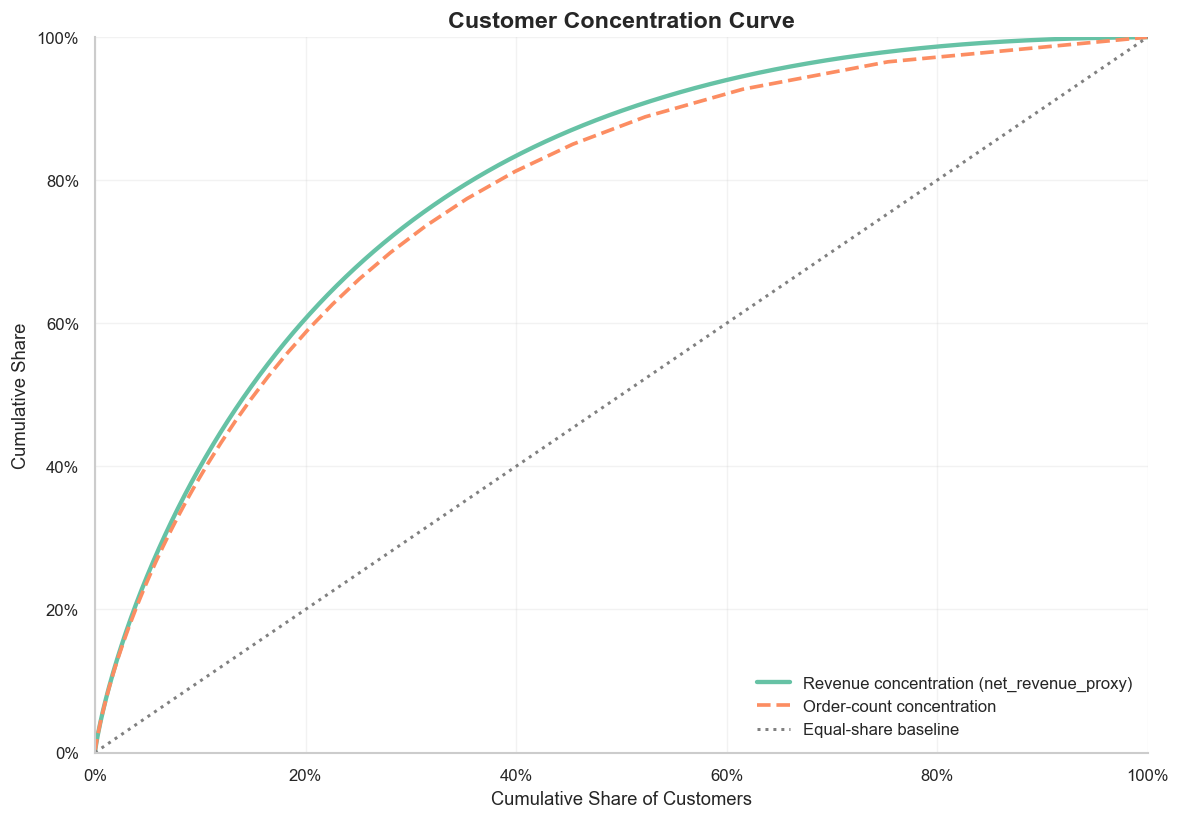

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(
    revenue_curve["cum_customer_share"],
    revenue_curve["cum_revenue_share"],
    label=f"Revenue concentration ({revenue_metric})",
    linewidth=2.6,
)
ax.plot(
    order_curve["cum_customer_share"],
    order_curve["cum_order_share"],
    label="Order-count concentration",
    linewidth=2.2,
    linestyle="--",
)
ax.plot(
    [0, 1],
    [0, 1],
    color="gray",
    linestyle=":",
    linewidth=1.8,
    label="Equal-share baseline",
)

ax.set_title("Customer Concentration Curve")
ax.set_xlabel("Cumulative Share of Customers")
ax.set_ylabel("Cumulative Share")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.tight_layout()